# 01. 데이터 이해와 탐색

용해탱크 KPI MLOps v1 — Notebook 기반 모델 개발

## 학습 목표

- 원본 데이터의 구조, 자료형, 결측치와 중복 여부를 확인한다.
- TAG 클래스 분포와 주요 센서 변수의 분포를 파악한다.
- 동일한 `STD_DT`에 10개 관측값이 존재하는지 확인한다.

> 이 Notebook은 모델을 만들기 전에 데이터가 어떤 의미인지 검증하는 단계입니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data/raw/melting_tank.csv"
QUICK_RUN = False  # 빠른 확인 시 True

print("Python:", sys.version.split()[0])
print("Data:", DATA_PATH)

Python: 3.12.14
Data: E:\academy\AI-DL\melting-tank-kpi-mlops_notebook_v1.0.0\data\raw\melting_tank.csv


In [2]:
df = pd.read_csv(DATA_PATH)
if QUICK_RUN:
    df = df.head(50_000).copy()

print("shape:", df.shape)
display(df.head())
df.info()

shape: (835200, 7)


,STD_DT,NUM,MELT_TEMP,MOTORSPEED,MELT_WEIGHT,INSP,TAG
0,2020-03-04 0:00,0,489,116,631,3.19,OK
1,2020-03-04 0:00,1,433,78,609,3.19,OK
2,2020-03-04 0:00,2,464,154,608,3.19,OK
3,2020-03-04 0:00,3,379,212,606,3.19,OK
4,2020-03-04 0:00,4,798,1736,604,3.21,OK


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835200 entries, 0 to 835199
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STD_DT       835200 non-null  object 
 1   NUM          835200 non-null  int64  
 2   MELT_TEMP    835200 non-null  int64  
 3   MOTORSPEED   835200 non-null  int64  
 4   MELT_WEIGHT  835200 non-null  int64  
 5   INSP         835200 non-null  float64
 6   TAG          835200 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 44.6+ MB


In [3]:
required = {"STD_DT", "MELT_TEMP", "MOTORSPEED", "MELT_WEIGHT", "INSP", "TAG"}
missing = sorted(required - set(df.columns))
assert not missing, f"필수 열 누락: {missing}"

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "nunique": df.nunique(),
})
display(quality)
print("완전 중복 행:", df.duplicated().sum())

,dtype,missing,nunique
STD_DT,object,0,83520
NUM,int64,0,835200
MELT_TEMP,int64,0,404
MOTORSPEED,int64,0,346
MELT_WEIGHT,int64,0,4050
INSP,float64,0,7
TAG,object,0,2


완전 중복 행: 0


In [4]:
display(df[["MELT_TEMP", "MOTORSPEED", "MELT_WEIGHT", "INSP"]].describe().T)
display(df["TAG"].value_counts(dropna=False).to_frame("count"))
display(df["TAG"].value_counts(normalize=True).rename("ratio").to_frame())

,count,mean,std,min,25%,50%,75%,max
MELT_TEMP,835200.0,509.200623,128.277519,308.00,430.00,469.00,502.0,832.00
MOTORSPEED,835200.0,459.782865,639.436413,0.00,119.00,168.00,218.0,1804.00
MELT_WEIGHT,835200.0,582.962125,1217.604433,0.00,186.00,383.00,583.0,55252.00
INSP,835200.0,3.194853,0.011822,3.17,3.19,3.19,3.2,3.23


,count
TAG,
OK,658133
NG,177067


,ratio
TAG,
OK,0.787994
NG,0.212006


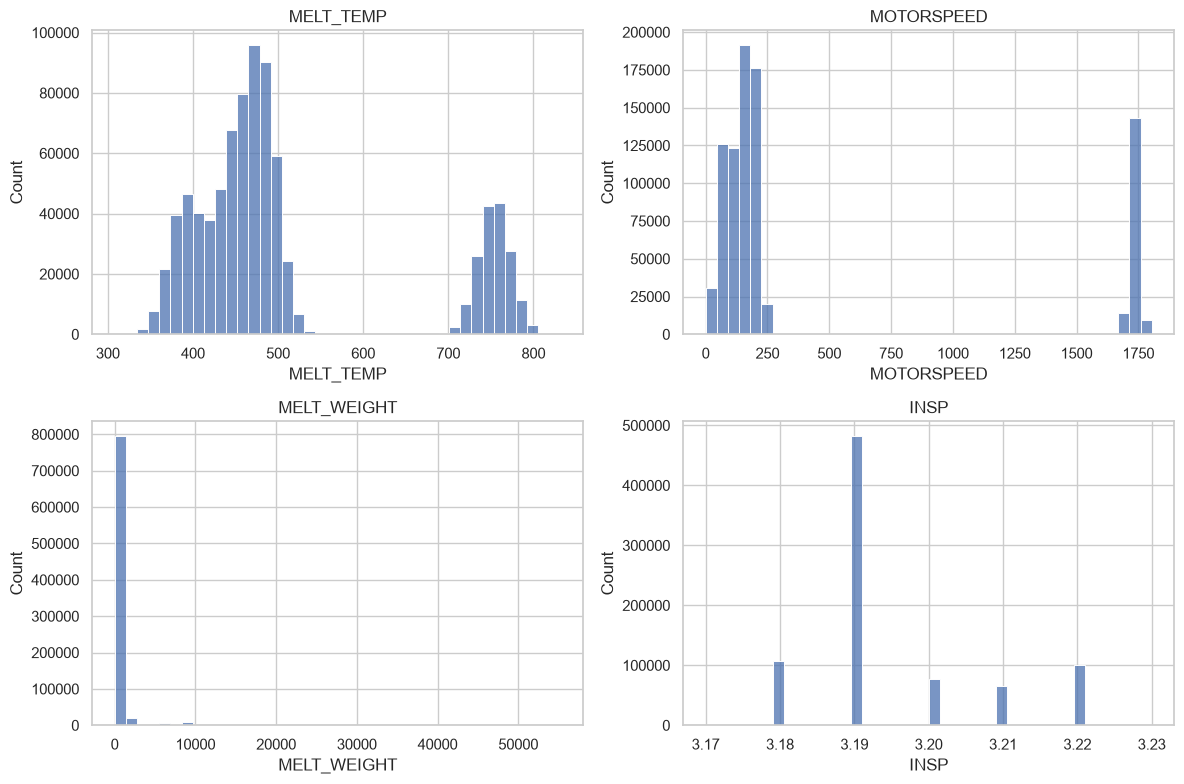

In [5]:
sns.set_theme(style="whitegrid")

features = ["MELT_TEMP", "MOTORSPEED", "MELT_WEIGHT", "INSP"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for feature, ax in zip(features, axes.flat):
    sns.histplot(df[feature], bins=40, ax=ax)
    ax.set_title(feature)
    
plt.tight_layout()
plt.show()

,minute_count
10,83520


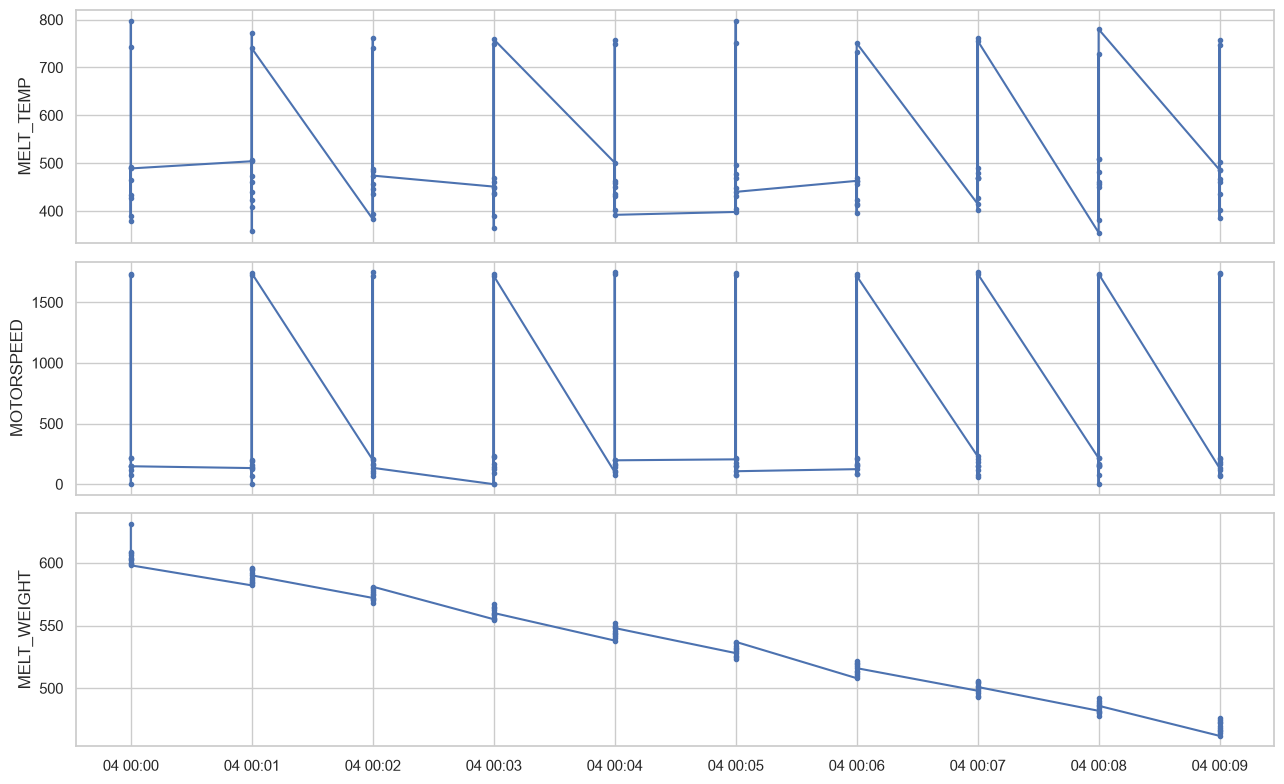

In [6]:
df["STD_DT"] = pd.to_datetime(df["STD_DT"], errors="raise")
observations_per_minute = df.groupby("STD_DT", sort=True).size()
display(observations_per_minute.value_counts().sort_index().rename("minute_count").to_frame())

sample = df.sort_values("STD_DT").head(100)
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

for feature, ax in zip(["MELT_TEMP", "MOTORSPEED", "MELT_WEIGHT"], axes):
    ax.plot(sample["STD_DT"], sample[feature], marker=".")
    ax.set_ylabel(feature)
    
plt.tight_layout()
plt.show()

## 해석 질문

1. TAG의 OK/NG 비율은 균형적인가?
2. 각 timestamp에 정확히 10개 행이 존재하는가?
3. `INSP`는 예측 시점에 얻을 수 있는 센서값인가, 검사 후 생성되는 값인가?
4. 시간에 따라 센서 분포나 NG 비율이 달라지는가?

`INSP`의 생성 시점을 확인하기 전까지는 데이터 누수를 방지하기 위해 모델 입력에서 제외합니다.